In [1]:
import sys                                                                                                                                                                                                        
sys.path.insert(0, '/home/svu/e1498138/emri_search/work')                                                                                                                                                   
                                                                                                                                                                                                                    
from GWfuncs_noise import GravWaveAnalysis, build_waveform_response                                                                                                                                                 
from loglike_timemax_noise import LogLike                                                                                                                                                                           
import numpy as np                                                                                                                                                                                                        
import cupy as cp

In [2]:
use_gpu=True                                                                                                                                       
T = 3/12        # years                 
dt = 5       # seconds

# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 9
e0 = 0.4
xI0 = 1.0
dist = 4.5  # Gpc
qS = np.pi
phiS = 0.
qK =  0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5                                                                                                                           
                                                                                                                                                                                                                                                                                                                                                    
                                        
waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=use_gpu,tdi_gen=1)                                                                                                    
         

In [3]:
params=[m1,m2,a,p0,e0,xI0,dist,qS,phiS,qK,phiK,Phi_phi0,Phi_theta0,Phi_r0]

In [4]:
# n-indexed mode selection parameters
n_vals = np.arange(-1,6)  # n from -1 to 5
ell = 2  # quadrupole only

In [5]:
gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=True,tdi_gen=1)

# no noise check

In [6]:


loglike_obj = LogLike(                                                                                                                                                                                                       
    params=params,                                                                                                                                                                                                  
    waveform_response=waveform_response,                                                                                                                                                                            
    gwf=gwf,                                                                                                                                                                                                      
    add_noise=False,
    verbose=True,
    ell=ell,                                                                                                                                                                                                          
    n_vals=n_vals,
    M_mode=None,                                                                                                                                                                                                    
)  

Delta_T for mode selection: 1577.9074881772797 seconds
Selected modes (l,m,n): [[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)], [(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)], [(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)], [(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)], [(2, 0, 3), (2, 1, 3), (2, 2, 3), (2, -1, 3), (2, -2, 3)], [(2, 0, 4), (2, 1, 4), (2, 2, 4), (2, -1, 4), (2, -2, 4)], [(2, 0, 5), (2, 1, 5), (2, 2, 5), (2, -1, 5), (2, -2, 5)]]
Selected modes: [[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)], [(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)], [(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)], [(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)], [(2, 0, 3), (2, 1, 3), (2, 2, 3), (2, -1, 3), (2, -2, 3)], [(2, 0, 4), (2, 1, 4), (2, 2, 4), (2, -1, 4), (2, -2, 4)], [(2, 0, 5), (2, 1, 5), (2, 2, 5), (2, -1, 5), (2, -2, 5)]]
Flattened modes: [(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), 

In [7]:
%%time
#loglike at true param
logl_true=loglike_obj(params)
print(logl_true)

Waveform amplitudes (time-maximized):
  Mode 0: <hf|hf>_timemax=0.9353, rho=0.9671
  Mode 1: <hf|hf>_timemax=4.212, rho=2.052
  Mode 2: <hf|hf>_timemax=28, rho=5.292
  Mode 3: <hf|hf>_timemax=36.68, rho=6.057
  Mode 4: <hf|hf>_timemax=23.79, rho=4.878
  Mode 5: <hf|hf>_timemax=10.29, rho=3.207
  Mode 6: <hf|hf>_timemax=3.464, rho=1.861
rho_m: [0.9670917  2.0523054  5.29161693 6.05657905 4.87775726 3.20720585
 1.86116828]
Dominant mode index: 3, rho: 6.057
beta=0.04288, rho_dom_M=6.057, rho_tot=10.99
X_scalar (time-maximized): 10.99
Time-maximized Log-likelihood: 10.9124
10.912364078973004
CPU times: user 208 ms, sys: 22 ms, total: 230 ms
Wall time: 303 ms


In [8]:
params_perturbed = list(params)                                                                                                                                                                                     
params_perturbed[0] *= 1.01                                                                                                                                                                                         
logl_perturbed = loglike_obj(params_perturbed)                                                                                                                                                                               
print(logl_perturbed)

Waveform amplitudes (time-maximized):
  Mode 0: <hf|hf>_timemax=0.8944, rho=0.9457
  Mode 1: <hf|hf>_timemax=4.032, rho=2.008
  Mode 2: <hf|hf>_timemax=26.99, rho=5.195
  Mode 3: <hf|hf>_timemax=35.67, rho=5.973
  Mode 4: <hf|hf>_timemax=23.35, rho=4.832
  Mode 5: <hf|hf>_timemax=10.17, rho=3.189
  Mode 6: <hf|hf>_timemax=3.443, rho=1.855
rho_m: [0.94571938 2.00790743 5.19520806 5.97284153 4.83223784 3.18893759
 1.85543446]
Dominant mode index: 3, rho: 5.973
beta=0.04364, rho_dom_M=5.973, rho_tot=10.84
X_scalar (time-maximized): 1.967
Time-maximized Log-likelihood: 0.419386
0.4193859077423545


In [9]:
import few
from GWfuncs_noise import GravWaveAnalysis, build_waveform_response
import loglike_timemax_noise
import loglike_phasemax_noise
import loglike_pure_noise
import loglike_tmXonly_noise


cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

use_gpu = True
tdi_gen = 1
T = 3/12
dt = 10

print('Building ResponseWrapper...')
waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=use_gpu, tdi_gen=tdi_gen)

print('Building GravWaveAnalysis...')
gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=use_gpu, tdi_gen=tdi_gen)

# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 9
e0 = 0.4
xI0 = 1.0
dist = 4.5  # Gpc
qS = np.pi
phiS = 0.
qK =  0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5   

params_star = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
param_true = np.array([np.log10(m1), np.log10(m2), a, p0, e0])

n_vals = np.arange(-1, 6)
ell = 2

print('Initializing loglike_tm...')
loglike_tm = loglike_timemax_noise.LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=False,
    verbose=True,
    ell=ell, n_vals=n_vals, M_mode=None,
)

print('Initializing loglike_pm...')
loglike_pm = loglike_phasemax_noise.LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=False,
    verbose=False,
    ell=ell, n_vals=n_vals, M_mode=None,
)

print('Initializing loglike_pure...')
loglike_p = loglike_pure_noise.LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=False,
    verbose=False,
    ell=ell, n_vals=n_vals, M_mode=None,
)

print('Initializing loglike_pure...')
loglike_tmX = loglike_tmXonly_noise.LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=False,
    verbose=False,
    ell=ell, n_vals=n_vals, M_mode=None,
)

def logden_tm(params):
    logm1, logm2, a, p0, e0 = params
    return float(loglike_tm(np.array([10**logm1, 10**logm2, a, p0, e0,
                                    xI0, dist, qS, phiS, qK, phiK,
                                    Phi_phi0, Phi_theta0, Phi_r0])))

def logden_pm(params):
    logm1, logm2, a, p0, e0 = params
    return float(loglike_pm(np.array([10**logm1, 10**logm2, a, p0, e0,
                                    xI0, dist, qS, phiS, qK, phiK,
                                    Phi_phi0, Phi_theta0, Phi_r0])))

def logden_pure(params):
    logm1, logm2, a, p0, e0 = params
    return float(loglike_p(np.array([10**logm1, 10**logm2, a, p0, e0,
                                    xI0, dist, qS, phiS, qK, phiK,
                                    Phi_phi0, Phi_theta0, Phi_r0])))

def logden_tmX(params):
    logm1, logm2, a, p0, e0 = params
    return float(loglike_tmX(np.array([10**logm1, 10**logm2, a, p0, e0,
                                    xI0, dist, qS, phiS, qK, phiK,
                                    Phi_phi0, Phi_theta0, Phi_r0])))

Building ResponseWrapper...
Building GravWaveAnalysis...
Initializing loglike_tm...
Delta_T for mode selection: 1577.9074881772797 seconds
Selected modes (l,m,n): [[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)], [(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)], [(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)], [(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)], [(2, 0, 3), (2, 1, 3), (2, 2, 3), (2, -1, 3), (2, -2, 3)], [(2, 0, 4), (2, 1, 4), (2, 2, 4), (2, -1, 4), (2, -2, 4)], [(2, 0, 5), (2, 1, 5), (2, 2, 5), (2, -1, 5), (2, -2, 5)]]
Selected modes: [[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)], [(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)], [(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)], [(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)], [(2, 0, 3), (2, 1, 3), (2, 2, 3), (2, -1, 3), (2, -2, 3)], [(2, 0, 4), (2, 1, 4), (2, 2, 4), (2, -1, 4), (2, -2, 4)], [(2, 0, 5), (2, 1, 5), (2, 2, 5), (2, -1, 

In [10]:
# Sanity check at true params
print(logden_tm(param_true), logden_pm(param_true), logden_pure(param_true)), logden_tmX(param_true)

Waveform amplitudes (time-maximized):
  Mode 0: <hf|hf>_timemax=0.9352, rho=0.9671
  Mode 1: <hf|hf>_timemax=4.212, rho=2.052
  Mode 2: <hf|hf>_timemax=28, rho=5.291
  Mode 3: <hf|hf>_timemax=36.68, rho=6.056
  Mode 4: <hf|hf>_timemax=23.79, rho=4.877
  Mode 5: <hf|hf>_timemax=10.28, rho=3.207
  Mode 6: <hf|hf>_timemax=3.462, rho=1.861
rho_m: [0.96707075 2.05221078 5.29111992 6.05627065 4.87744854 3.20666188
 1.86069503]
Dominant mode index: 3, rho: 6.056
beta=0.04288, rho_dom_M=6.056, rho_tot=10.99
X_scalar (time-maximized): 10.99
Time-maximized Log-likelihood: 10.9116
10.911576753079219 10.91165190184334 10.91165190184334


(None, 10.911576753079219)

In [11]:
# Sweep over logm2
param_idx = 1  # logm2
# param_secondary = np.array([6.29332246, 0.97236086, 0.3347499, 10.18644061, 0.34722833])

param_range = np.sort(np.append(np.linspace(0.99, 1.01, 200), param_true[param_idx]))

f_stats_tm   = np.zeros(len(param_range))
f_stats_pm   = np.zeros(len(param_range))
f_stats_pure = np.zeros(len(param_range))
f_stats_tmX = np.zeros(len(param_range))
X_pure = np.zeros(len(param_range))
X_tm = np.zeros(len(param_range))


for i, val in enumerate(param_range):

    p = param_true.copy()
    p[param_idx] = val
    f_stats_tm[i]   = logden_tm(p)
    f_stats_pm[i]   = logden_pm(p)
    f_stats_pure[i] = logden_pure(p)
    f_stats_tmX[i] = logden_tmX(p)

    # X only (no chi_sq)
    logm1, logm2, a_i, p0_i, e0_i = p
    h = gwf.xp.array(waveform_response(
        10**logm1, 10**logm2, a_i, p0_i, e0_i,
        xI0, dist, qS, phiS, qK, phiK,
        Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt,
    ))
    h_fft_r = gwf.freq_wave(h)
    rho_h   = float(gwf.xp.sqrt(gwf.inner(h_fft_r, h_fft_r)))
    X_pure[i] = float(gwf.inner(loglike_p.signal_fft, h_fft_r, return_complex=False)) / rho_h
    X_tm[i] = float(gwf.inner_timemax(loglike_p.signal, h)) / rho_h

Waveform amplitudes (time-maximized):
  Mode 0: <hf|hf>_timemax=0.8895, rho=0.9431
  Mode 1: <hf|hf>_timemax=3.997, rho=1.999
  Mode 2: <hf|hf>_timemax=26.63, rho=5.161
  Mode 3: <hf|hf>_timemax=34.96, rho=5.913
  Mode 4: <hf|hf>_timemax=22.71, rho=4.766
  Mode 5: <hf|hf>_timemax=9.833, rho=3.136
  Mode 6: <hf|hf>_timemax=3.314, rho=1.821
rho_m: [0.94311316 1.99921274 5.16080982 5.91260293 4.76583157 3.13568704
 1.82053732]
Dominant mode index: 3, rho: 5.913
beta=0.04437, rho_dom_M=5.913, rho_tot=10.73
X_scalar (time-maximized): 2.255
Time-maximized Log-likelihood: 0.571147
Waveform amplitudes (time-maximized):
  Mode 0: <hf|hf>_timemax=0.8899, rho=0.9433
  Mode 1: <hf|hf>_timemax=3.999, rho=2
  Mode 2: <hf|hf>_timemax=26.65, rho=5.162
  Mode 3: <hf|hf>_timemax=34.98, rho=5.914
  Mode 4: <hf|hf>_timemax=22.72, rho=4.767
  Mode 5: <hf|hf>_timemax=9.837, rho=3.136
  Mode 6: <hf|hf>_timemax=3.317, rho=1.821
rho_m: [0.94334998 1.9997391  5.16209968 5.91401229 4.76694637 3.13643656
 1.82116

In [12]:
import matplotlib.pyplot as plt

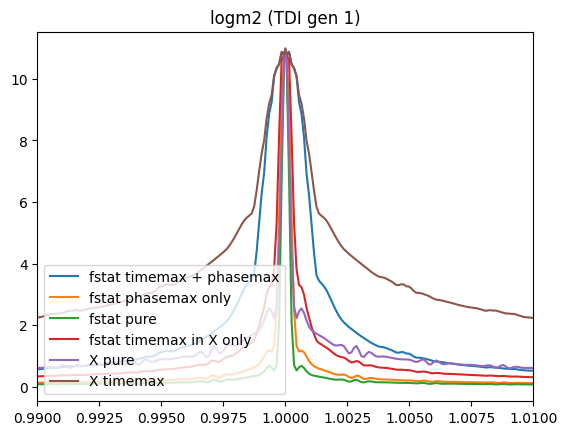

In [13]:
plt.plot(param_range, f_stats_tm,   label='fstat timemax + phasemax')
plt.plot(param_range, f_stats_pm,   label='fstat phasemax only')
plt.plot(param_range, f_stats_pure, label='fstat pure')
plt.plot(param_range, f_stats_tmX, label='fstat timemax in X only')
plt.plot(param_range, X_pure, label='X pure')
plt.plot(param_range, X_tm, label='X timemax')

plt.xlim(0.99, 1.01)
plt.title('logm2 (TDI gen 1)')
plt.legend(loc='lower left')
plt.show()

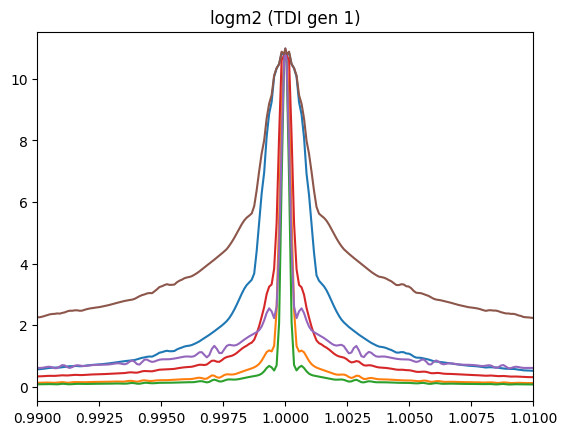

In [14]:
plt.plot(param_range, f_stats_tm,   label='fstat timemax + phasemax')
plt.plot(param_range, f_stats_pm,   label='fstat phasemax only')
plt.plot(param_range, f_stats_pure, label='fstat pure')
plt.plot(param_range, f_stats_tmX, label='fstat timemax in X only')
plt.plot(param_range, X_pure, label='X pure')
plt.plot(param_range, X_tm, label='X timemax')

plt.xlim(0.99, 1.01)
plt.title('logm2 (TDI gen 1)')
# plt.legend(loc='lower left')
plt.show()

# check with noise/

In [15]:


loglike_obj_noise = LogLike(                                                                                                                                                                                                       
    params=params,                                                                                                                                                                                                  
    waveform_response=waveform_response,                                                                                                                                                                            
    gwf=gwf,                                                                                                                                                                                                      
    add_noise=True,
    verbose=True,
    ell=ell,                                                                                                                                                                                                          
    n_vals=n_vals,
    M_mode=None,                                                                                                                                                                                                    
)  

[INFO] Added colored noise with seed=0
Delta_T for mode selection: 1577.9074881772797 seconds
Selected modes (l,m,n): [[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)], [(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)], [(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)], [(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)], [(2, 0, 3), (2, 1, 3), (2, 2, 3), (2, -1, 3), (2, -2, 3)], [(2, 0, 4), (2, 1, 4), (2, 2, 4), (2, -1, 4), (2, -2, 4)], [(2, 0, 5), (2, 1, 5), (2, 2, 5), (2, -1, 5), (2, -2, 5)]]
Selected modes: [[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)], [(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)], [(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)], [(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)], [(2, 0, 3), (2, 1, 3), (2, 2, 3), (2, -1, 3), (2, -2, 3)], [(2, 0, 4), (2, 1, 4), (2, 2, 4), (2, -1, 4), (2, -2, 4)], [(2, 0, 5), (2, 1, 5), (2, 2, 5), (2, -1, 5), (2, -2, 5)]]
Flattened modes: [(2, 0, -1)

In [16]:
#loglike at true param
logl_true_noise=loglike_obj_noise(params)
print(logl_true_noise)

Waveform amplitudes (time-maximized):
  Mode 0: <hf|hf>_timemax=0.9352, rho=0.9671
  Mode 1: <hf|hf>_timemax=4.212, rho=2.052
  Mode 2: <hf|hf>_timemax=28, rho=5.291
  Mode 3: <hf|hf>_timemax=36.68, rho=6.056
  Mode 4: <hf|hf>_timemax=23.79, rho=4.877
  Mode 5: <hf|hf>_timemax=10.28, rho=3.207
  Mode 6: <hf|hf>_timemax=3.462, rho=1.861
rho_m: [0.96707075 2.05221078 5.29111992 6.05627065 4.87744854 3.20666188
 1.86069503]
Dominant mode index: 3, rho: 6.056
beta=0.04288, rho_dom_M=6.056, rho_tot=10.99
X_scalar (time-maximized): 12.63
Time-maximized Log-likelihood: 10.9656
10.965565530077226


In [17]:
                                                                                                                                                                                       
logl_perturbed_noise = loglike_obj_noise(params_perturbed)                                                                                                                                                                               
print(logl_perturbed_noise)

Waveform amplitudes (time-maximized):
  Mode 0: <hf|hf>_timemax=0.8943, rho=0.9457
  Mode 1: <hf|hf>_timemax=4.031, rho=2.008
  Mode 2: <hf|hf>_timemax=26.99, rho=5.195
  Mode 3: <hf|hf>_timemax=35.67, rho=5.972
  Mode 4: <hf|hf>_timemax=23.34, rho=4.832
  Mode 5: <hf|hf>_timemax=10.17, rho=3.188
  Mode 6: <hf|hf>_timemax=3.441, rho=1.855
rho_m: [0.94569309 2.0078329  5.19494047 5.97228635 4.83151992 3.18838729
 1.85501442]
Dominant mode index: 3, rho: 5.972
beta=0.04365, rho_dom_M=5.972, rho_tot=10.84
X_scalar (time-maximized): 4.555
Time-maximized Log-likelihood: 2.34564
2.345643212375881


# 1 yr with noise

In [17]:
gwf_1yr=GravWaveAnalysis(T=1, dt=dt, use_gpu=True,tdi_gen=1)
waveform_response_1yr = build_waveform_response(T=1, dt=dt, use_gpu=use_gpu,tdi_gen=1)                                                                                                    

loglike_1yr = LogLike(                                                                                                                                                                                                       
    params=params,                                                                                                                                                                                                  
    waveform_response=waveform_response_1yr,                                                                                                                                                                            
    gwf=gwf_1yr,                                                                                                                                                                                                      
    add_noise=True,
    verbose=True,
    ell=ell,                                                                                                                                                                                                          
    n_vals=n_vals,
    M_mode=None,                                                                                                                                                                                                    
)  

[INFO] Added colored noise with seed=0
Delta_T for mode selection: 6311.629952709119 seconds
Selected modes (l,m,n): [[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)], [(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)], [(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)], [(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)], [(2, 0, 3), (2, 1, 3), (2, 2, 3), (2, -1, 3), (2, -2, 3)], [(2, 0, 4), (2, 1, 4), (2, 2, 4), (2, -1, 4), (2, -2, 4)], [(2, 0, 5), (2, 1, 5), (2, 2, 5), (2, -1, 5), (2, -2, 5)]]
Selected modes: [[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)], [(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)], [(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)], [(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)], [(2, 0, 3), (2, 1, 3), (2, 2, 3), (2, -1, 3), (2, -2, 3)], [(2, 0, 4), (2, 1, 4), (2, 2, 4), (2, -1, 4), (2, -2, 4)], [(2, 0, 5), (2, 1, 5), (2, 2, 5), (2, -1, 5), (2, -2, 5)]]
Flattened modes: [(2, 0, -1),

In [18]:
#loglike at true param
logl_1yr=loglike_1yr(params)
print(logl_1yr)

Waveform amplitudes (time-maximized):
  Mode 0: <hf|hf>_timemax=7.316, rho=2.705
  Mode 1: <hf|hf>_timemax=45.86, rho=6.772
  Mode 2: <hf|hf>_timemax=196.8, rho=14.03
  Mode 3: <hf|hf>_timemax=187.7, rho=13.7
  Mode 4: <hf|hf>_timemax=93.88, rho=9.689
  Mode 5: <hf|hf>_timemax=32.98, rho=5.743
  Mode 6: <hf|hf>_timemax=9.393, rho=3.065
rho_m: [ 2.70474955  6.77214812 14.02851306 13.70036345  9.68896259  5.74259501
  3.06485009]
Dominant mode index: 2, rho: 14.03
beta=0.01186, rho_dom_M=14.03, rho_tot=25.34
X_scalar (time-maximized): 22.32
Time-maximized Log-likelihood: 20.7155
20.715541774376174


# check orthogonality

In [19]:
waveforms_per_group = []
groups = [
    [(2,-2,-1),(2,-1,-1),  (2,0,-1), (2,1,-1), (2,2,-1)],#0
    [(2,-2,0),(2,-1,0),  (2,0,0), (2,1,0), (2,2,0)],#1
    [(2,-2,1),(2,-1,1),  (2,0,1), (2,1,1), (2,2,1)],#2
    [(2,-2,2),(2,-1,2),  (2,0,2), (2,1,2), (2,2,2)],#3
    [(2,-2,3),(2,-1,3),  (2,0,3), (2,1,3), (2,2,3)],#4
    [(2,-2,4),(2,-1,4),  (2,0,4), (2,1,4), (2,2,4)],#5
    [(2,-2,5),(2,-1,5),  (2,0,5), (2,1,5), (2,2,5)],#6
]
params = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
waveforms = [   
    cp.array(waveform_response(*params, T=T, dt=dt, mode_selection=g, include_minus_mkn=False))                                                                                    
    for g in groups                                                                                                                                                                
]

In [29]:
n = len(groups)                                                                                                                                                                    
overlap_matrix = np.zeros((n, n))
                                                                                                                                                                                    
for i in range(n):
    for j in range(n):
        hi_f = gwf.freq_wave(waveforms[i])
        hj_f = gwf.freq_wave(waveforms[j])                                                                                                                                         
        overlap_matrix[i, j] = float(cp.real(gwf.overlap(hi_f, hj_f)))   

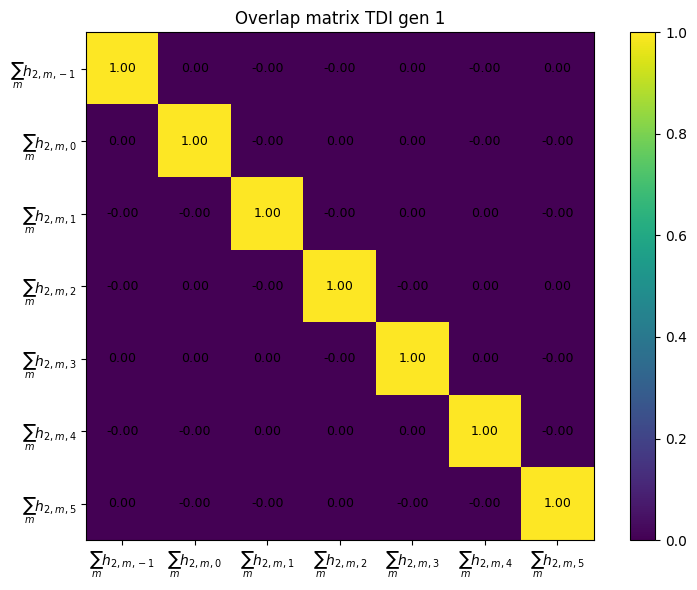

In [30]:
# Display as heatmap
labels = [                                                                                                                                                                                       
    r'$\sum_m h_{2,m,-1}$',                                                      
    r'$\sum_m h_{2,m,0}$',                                                                                                                                                                         
    r'$\sum_m h_{2,m,1}$',                                                                                                                                                                         
    r'$\sum_m h_{2,m,2}$',                                                                                                                                                                         
    r'$\sum_m h_{2,m,3}$',                                                                                                                                                                         
    r'$\sum_m h_{2,m,4}$',                                                                                                                                                                       
    r'$\sum_m h_{2,m,5}$',
]
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))                                                                                                                                             
im = ax.imshow(overlap_matrix, cmap='viridis', vmin=0, vmax=1)
ax.set_xticks(range(n)); ax.set_xticklabels(labels)                                                                                                                                
ax.set_yticks(range(n)); ax.set_yticklabels(labels)
ax.set_title('Overlap matrix TDI gen 1')                                                                                                                                          
plt.colorbar(im, ax=ax)
for i in range(n):                                                                                                                                                                 
    for j in range(n):                                                                                                                                                             
        ax.text(j, i, f'{overlap_matrix[i,j]:.2f}', ha='center', va='center', fontsize=9)
plt.tight_layout()                                                                                                                                                                 
plt.show() 

In [31]:
overlap_matrix

array([[ 1.00000000e+00,  2.18892408e-05, -4.43025349e-05,
        -2.77480301e-05,  2.71039462e-05, -3.47458835e-05,
         5.91293487e-05],
       [ 2.18892408e-05,  1.00000000e+00, -2.07615539e-05,
         1.90113415e-05,  4.01963940e-05, -1.31520446e-04,
        -4.52887570e-06],
       [-4.43025349e-05, -2.07615539e-05,  1.00000000e+00,
        -1.17586369e-05,  1.12744634e-04,  1.04776724e-04,
        -2.86425714e-04],
       [-2.77480301e-05,  1.90113415e-05, -1.17586369e-05,
         1.00000000e+00, -7.13185786e-06,  1.21751187e-04,
         1.07469621e-04],
       [ 2.71039462e-05,  4.01963940e-05,  1.12744634e-04,
        -7.13185786e-06,  1.00000000e+00,  1.67450799e-06,
        -1.45960061e-05],
       [-3.47458835e-05, -1.31520446e-04,  1.04776724e-04,
         1.21751187e-04,  1.67450799e-06,  1.00000000e+00,
        -2.11200617e-05],
       [ 5.91293487e-05, -4.52887570e-06, -2.86425714e-04,
         1.07469621e-04, -1.45960061e-05, -2.11200617e-05,
         1.0000000

# conditionals 3 mth

In [18]:
  import few
from GWfuncs_noise import GravWaveAnalysis, build_waveform_response
import loglike_timemax_noise
import loglike_phasemax_noise
import loglike_pure_noise
import loglike_tmXonly_noise


cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

use_gpu = True
tdi_gen = 1
T = 3/12
dt = 10

print('Building ResponseWrapper...')
waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=use_gpu, tdi_gen=tdi_gen)

print('Building GravWaveAnalysis...')
gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=use_gpu, tdi_gen=tdi_gen)

# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 9
e0 = 0.4
xI0 = 1.0
dist = 4.5  # Gpc
qS = np.pi
phiS = 0.
qK =  0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5   

params_star = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
param_true = np.array([np.log10(m1), np.log10(m2), a, p0, e0])

n_vals = np.arange(-1, 6)
ell = 2

print('Initializing loglike_tm...')
loglike_tm = loglike_timemax_noise.LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    verbose=True,
    ell=ell, n_vals=n_vals, M_mode=None,
)

print('Initializing loglike_pm...')
loglike_pm = loglike_phasemax_noise.LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    verbose=False,
    ell=ell, n_vals=n_vals, M_mode=None,
)

print('Initializing loglike_pure...')
loglike_p = loglike_pure_noise.LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    verbose=False,
    ell=ell, n_vals=n_vals, M_mode=None,
)

print('Initializing loglike_pure...')
loglike_tmX = loglike_tmXonly_noise.LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    verbose=False,
    ell=ell, n_vals=n_vals, M_mode=None,
)

def logden_tm(params):
    logm1, logm2, a, p0, e0 = params
    return float(loglike_tm(np.array([10**logm1, 10**logm2, a, p0, e0,
                                    xI0, dist, qS, phiS, qK, phiK,
                                    Phi_phi0, Phi_theta0, Phi_r0])))

def logden_pm(params):
    logm1, logm2, a, p0, e0 = params
    return float(loglike_pm(np.array([10**logm1, 10**logm2, a, p0, e0,
                                    xI0, dist, qS, phiS, qK, phiK,
                                    Phi_phi0, Phi_theta0, Phi_r0])))

def logden_pure(params):
    logm1, logm2, a, p0, e0 = params
    return float(loglike_p(np.array([10**logm1, 10**logm2, a, p0, e0,
                                    xI0, dist, qS, phiS, qK, phiK,
                                    Phi_phi0, Phi_theta0, Phi_r0])))

def logden_tmX(params):
    logm1, logm2, a, p0, e0 = params
    return float(loglike_tmX(np.array([10**logm1, 10**logm2, a, p0, e0,
                                    xI0, dist, qS, phiS, qK, phiK,
                                    Phi_phi0, Phi_theta0, Phi_r0])))

Building ResponseWrapper...
Building GravWaveAnalysis...
Initializing loglike_tm...
[INFO] Added colored noise with seed=0
Delta_T for mode selection: 1577.9074881772797 seconds
Selected modes (l,m,n): [[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)], [(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)], [(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)], [(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)], [(2, 0, 3), (2, 1, 3), (2, 2, 3), (2, -1, 3), (2, -2, 3)], [(2, 0, 4), (2, 1, 4), (2, 2, 4), (2, -1, 4), (2, -2, 4)], [(2, 0, 5), (2, 1, 5), (2, 2, 5), (2, -1, 5), (2, -2, 5)]]
Selected modes: [[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)], [(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)], [(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)], [(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)], [(2, 0, 3), (2, 1, 3), (2, 2, 3), (2, -1, 3), (2, -2, 3)], [(2, 0, 4), (2, 1, 4), (2, 2, 4), (2, -1, 4), (2, -2, 4)], [(2

In [19]:
# Sanity check at true params
print(logden_tm(param_true), logden_pm(param_true), logden_pure(param_true)), logden_tmX(param_true)

Waveform amplitudes (time-maximized):
  Mode 0: <hf|hf>_timemax=0.9352, rho=0.9671
  Mode 1: <hf|hf>_timemax=4.212, rho=2.052
  Mode 2: <hf|hf>_timemax=28, rho=5.291
  Mode 3: <hf|hf>_timemax=36.68, rho=6.056
  Mode 4: <hf|hf>_timemax=23.79, rho=4.877
  Mode 5: <hf|hf>_timemax=10.28, rho=3.207
  Mode 6: <hf|hf>_timemax=3.462, rho=1.861
rho_m: [0.96707075 2.05221078 5.29111992 6.05627065 4.87744854 3.20666188
 1.86069503]
Dominant mode index: 3, rho: 6.056
beta=0.04288, rho_dom_M=6.056, rho_tot=10.99
X_scalar (time-maximized): 12.63
Time-maximized Log-likelihood: 10.9656
10.965565530077226 11.1742836581672 11.202590462881382


(None, 10.968288679753538)

In [20]:
param_true

array([6. , 1. , 0.7, 9. , 0.4])

In [21]:
# Sweep over logm2
param_idx = 1  # logm2
# param_secondary = np.array([6.29332246, 0.97236086, 0.3347499, 10.18644061, 0.34722833])

param_range = np.sort(np.append(np.linspace(0.99, 1.01, 200), param_true[param_idx]))

f_stats_tm   = np.zeros(len(param_range))
f_stats_pm   = np.zeros(len(param_range))
f_stats_pure = np.zeros(len(param_range))
f_stats_tmX = np.zeros(len(param_range))
X_pure = np.zeros(len(param_range))
X_tm = np.zeros(len(param_range))


for i, val in enumerate(param_range):

    p = param_true.copy()
    p[param_idx] = val
    f_stats_tm[i]   = logden_tm(p)
    f_stats_pm[i]   = logden_pm(p)
    f_stats_pure[i] = logden_pure(p)
    f_stats_tmX[i] = logden_tmX(p)

    # X only (no chi_sq)
    logm1, logm2, a_i, p0_i, e0_i = p
    h = gwf.xp.array(waveform_response(
        10**logm1, 10**logm2, a_i, p0_i, e0_i,
        xI0, dist, qS, phiS, qK, phiK,
        Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt,
    ))
    h_fft_r = gwf.freq_wave(h)
    rho_h   = float(gwf.xp.sqrt(gwf.inner(h_fft_r, h_fft_r)))
    X_pure[i] = float(gwf.inner(loglike_p.signal_fft, h_fft_r, return_complex=False)) / rho_h
    X_tm[i] = float(gwf.inner_timemax(loglike_p.signal, h)) / rho_h

Waveform amplitudes (time-maximized):
  Mode 0: <hf|hf>_timemax=0.8895, rho=0.9431
  Mode 1: <hf|hf>_timemax=3.997, rho=1.999
  Mode 2: <hf|hf>_timemax=26.63, rho=5.161
  Mode 3: <hf|hf>_timemax=34.96, rho=5.913
  Mode 4: <hf|hf>_timemax=22.71, rho=4.766
  Mode 5: <hf|hf>_timemax=9.833, rho=3.136
  Mode 6: <hf|hf>_timemax=3.314, rho=1.821
rho_m: [0.94311316 1.99921274 5.16080982 5.91260293 4.76583157 3.13568704
 1.82053732]
Dominant mode index: 3, rho: 5.913
beta=0.04437, rho_dom_M=5.913, rho_tot=10.73
X_scalar (time-maximized): 4.763
Time-maximized Log-likelihood: 2.62328
Waveform amplitudes (time-maximized):
  Mode 0: <hf|hf>_timemax=0.8899, rho=0.9433
  Mode 1: <hf|hf>_timemax=3.999, rho=2
  Mode 2: <hf|hf>_timemax=26.65, rho=5.162
  Mode 3: <hf|hf>_timemax=34.98, rho=5.914
  Mode 4: <hf|hf>_timemax=22.72, rho=4.767
  Mode 5: <hf|hf>_timemax=9.837, rho=3.136
  Mode 6: <hf|hf>_timemax=3.317, rho=1.821
rho_m: [0.94334998 1.9997391  5.16209968 5.91401229 4.76694637 3.13643656
 1.821169

In [22]:
def get_separatrix(a, e0):
    from few.utils.geodesic import get_separatrix
    return get_separatrix(a, e0, 1.0)  # xI=1 (prograde)

In [23]:
get_separatrix(0.335, 0.347)

5.433423987089838

In [24]:
f_stats_tmX

array([ 1.65081337,  1.67932279,  1.66272814,  1.56514021,  1.47763785,
        1.44455137,  1.50845704,  1.47216737,  1.31187684,  1.22890065,
        1.28928142,  1.46856429,  1.52733162,  1.60845167,  1.54997674,
        1.43857069,  1.29237275,  1.21161767,  1.23487619,  1.29426398,
        1.42798308,  1.39177727,  1.17831548,  1.11848663,  1.16127039,
        1.19882268,  1.24452549,  1.24012593,  1.18411045,  1.15126963,
        1.01540652,  0.90259028,  0.99767578,  1.09084702,  1.0715274 ,
        0.99258337,  0.90859585,  0.9720135 ,  1.16450344,  1.29626183,
        1.32367108,  1.28485542,  1.24328922,  1.22243415,  1.30739113,
        1.32946081,  1.30733794,  1.30308851,  1.29844355,  1.29565789,
        1.27983222,  1.26299768,  1.16382081,  1.15024491,  1.23030386,
        1.28939238,  1.24259961,  1.25317782,  1.26719389,  1.1042677 ,
        1.26229247,  1.60722564,  1.83552822,  1.90034164,  1.85732177,
        1.71446298,  1.49915349,  1.43527574,  1.78289066,  2.44

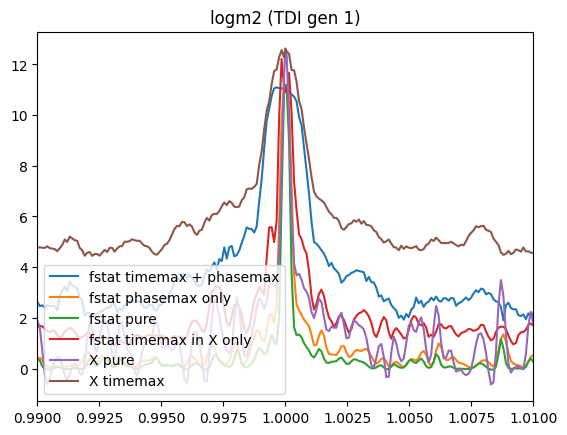

In [25]:
plt.plot(param_range, f_stats_tm,   label='fstat timemax + phasemax')
plt.plot(param_range, f_stats_pm,   label='fstat phasemax only')
plt.plot(param_range, f_stats_pure, label='fstat pure')
plt.plot(param_range, f_stats_tmX, label='fstat timemax in X only')
plt.plot(param_range, X_pure, label='X pure')
plt.plot(param_range, X_tm, label='X timemax')

plt.xlim(0.99, 1.01)
plt.title('logm2 (TDI gen 1)')
plt.legend(loc='lower left')
plt.show()

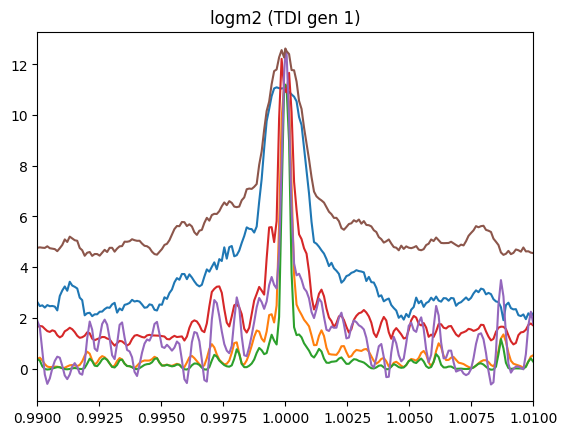

In [26]:
plt.plot(param_range, f_stats_tm,   label='fstat timemax + phasemax')
plt.plot(param_range, f_stats_pm,   label='fstat phasemax only')
plt.plot(param_range, f_stats_pure, label='fstat pure')
plt.plot(param_range, f_stats_tmX, label='fstat timemax in X only')
plt.plot(param_range, X_pure, label='X pure')
plt.plot(param_range, X_tm, label='X timemax')

plt.xlim(0.99, 1.01)
plt.title('logm2 (TDI gen 1)')
# plt.legend(loc='lower left')
plt.show()